In [1]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from copy import deepcopy
import joblib
import sys
sys.path.append('/content/CSI5388-Group1-Project/src')
from data_preprocessing import create_train_test_val_sets

In [4]:
import sys
sys.path.append('/content/CSI5388-Group1-Project/src')
import data_preprocessing as dp
import pandas as pd

def load_datasets():
    mendeley_df = pd.read_csv("/content/drive/MyDrive/CSI5388 A2/Phishing Detection Datasetm/Mendeley Dataset.csv")
    phiusiil_df = pd.read_csv("/content/drive/MyDrive/CSI5388 A2/phiusiil+phishing+url+dataset/PhiUSIIL Dataset.csv")
    mendeley_df = mendeley_df.rename(columns={'Type': 'Label'})
    phiusiil_df = phiusiil_df.rename(columns={'label': 'Label'})
    return mendeley_df, phiusiil_df

dp.load_datasets = load_datasets

# Run preprocessing - this gives us the processed data directly
mendeley_df, phiusiil_df = dp.load_datasets()

mendeley_processed = dp.process_data(mendeley_df)
y_mendeley = mendeley_processed["Label"]
x_mendeley = mendeley_processed.drop(columns=["Label"])

phiusiil_processed = dp.process_data(phiusiil_df)
y_phiusiil = phiusiil_processed["Label"]
x_phiusiil = phiusiil_processed.drop(columns=["Label"])

# Now create splits
from data_preprocessing import create_train_test_val_sets
mendeley_sets = create_train_test_val_sets(x_mendeley, y_mendeley, label_col="Label", test_size=0.2, n_splits=5)
phiusiil_sets = create_train_test_val_sets(x_phiusiil, y_phiusiil, label_col="Label", test_size=0.2, n_splits=5)


Class Distribution:
Label
0    0.518415
1    0.481585
Name: proportion, dtype: float64

Total Missing Values: 0
No categorical features to hash
Shape After Processing: (247950, 42)
True

Class Distribution:
Label
1    0.571895
0    0.428105
Name: proportion, dtype: float64

Total Missing Values: 0
Shape After Processing: (235795, 10355)
True
Train/validation/test split prepared: 198360 instances for training and validation, 49590 instances for testing
Stratified 5-fold CV splits created.
Train/validation/test split prepared: 188636 instances for training and validation, 47159 instances for testing
Stratified 5-fold CV splits created.


In [5]:
import os
os.makedirs("./models/phase_1", exist_ok=True)

In [6]:
print("Random Forest Mendeley:")
rf_mendeley = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    max_features='sqrt',
    class_weight=None,
    random_state=42,
    n_jobs=-1
)
joblib.dump(rf_mendeley, "./models/phase_1/rf_mendeley_no_fs.joblib")

print("Random Forest PhiUSIIL:")
rf_phiusiil = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
joblib.dump(rf_phiusiil, "./models/phase_1/rf_phiusiil_no_fs.joblib")

Random Forest Mendeley:
Random Forest PhiUSIIL:


['./models/phase_1/rf_phiusiil_no_fs.joblib']

In [7]:


def train_no_feature_selection(dataset, model):
    model.fit(dataset["x_train_val"], dataset["y_train_val"])
    y_test_pred = model.predict(dataset["x_test"])

    print("Test Set Performance")
    cm = confusion_matrix(dataset["y_test"], y_test_pred)
    ConfusionMatrixDisplay(cm).plot()
    print(classification_report(dataset["y_test"], y_test_pred))

Random Forest Mendeley Results:
Test Set Performance
              precision    recall  f1-score   support

           0       0.96      0.97      0.97     25708
           1       0.97      0.96      0.97     23882

    accuracy                           0.97     49590
   macro avg       0.97      0.97      0.97     49590
weighted avg       0.97      0.97      0.97     49590

Random Forest PhiUSIIL Results:
Test Set Performance
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



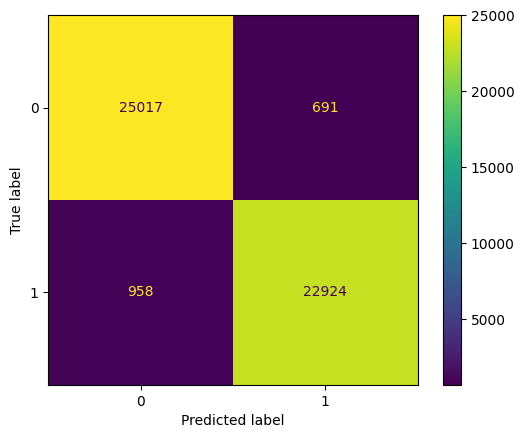

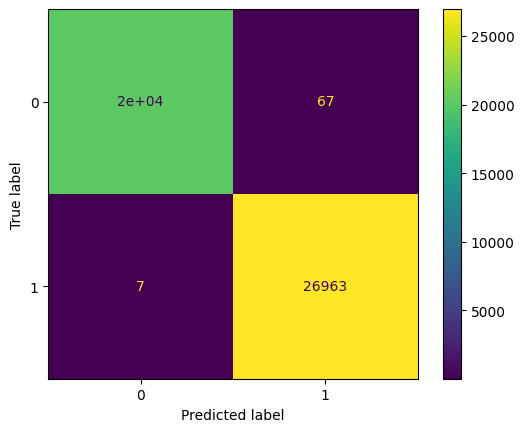

In [8]:
rf_mendeley_baseline_no_fs = deepcopy(rf_mendeley)
rf_phiusiil_baseline_no_fs = deepcopy(rf_phiusiil)

print('Random Forest Mendeley Results:')
train_no_feature_selection(mendeley_sets, rf_mendeley_baseline_no_fs)

print('Random Forest PhiUSIIL Results:')
train_no_feature_selection(phiusiil_sets, rf_phiusiil_baseline_no_fs)